#Imports

In [13]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import ndcg_score, average_precision_score
from sklearn.metrics import f1_score


#Data preparation

In [18]:
df = pd.read_csv("final df.csv")
df.head()

,cv_id,jd_id,matched_weight,required_weight,match_ratio,missing_required_skills_count,missing_hard_skills,missing_soft_skills,required_hard_skills,required_soft_skills,...,feat_68,feat_117,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8
0,1,1,1,1,1.000000,0,[],['adaptability'],['ai'],"['teamwork', 'leadership', 'customer focus', '...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967
1,1,2,3,4,0.750000,1,['systems engineering'],"['communication', 'problem solving']","['ai', 'systems engineering', 'financial analy...","['communication', 'problem solving']",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967
2,1,3,1,3,0.333333,2,"['marketing', 'microsoft office']",[],"['ai', 'marketing', 'microsoft office']","['teamwork', 'leadership', 'growth mindset']",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967
3,1,4,1,3,0.333333,2,"['sales', 'product management']","['problem solving', 'time management', 'work e...","['ai', 'sales', 'product management']","['problem solving', 'leadership', 'time manage...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967
4,1,5,5,8,0.625000,3,"['networking', 'sales', 'product management']","['problem solving', 'adaptability', 'attention...","['ai', 'models', 'reporting', 'networking', 's...","['teamwork', 'problem solving', 'leadership', ...",...,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967


In [19]:
df.shape

(10176, 33)

In [20]:
from sklearn.preprocessing import LabelEncoder
if 'match_ratio' in df.columns:
    df.rename(columns={'match_ratio': 'hard_skill_match_ratio'}, inplace=True)

le = LabelEncoder()
df['domain_encoded'] = le.fit_transform(df['domain'])

df['missing_soft_skills_count_new'] = df['missing_soft_skills_count_new'].apply(
    lambda x: len(x) if isinstance(x, list) else x
)

In [45]:
FEATURES = [
    'feat_95', 'feat_69', 'feat_125', 'feat_20', 'feat_91',
    'feat_68', 'feat_117', 'feat_76', 'feat_11', 'feat_88',
    'feat_94', 'feat_27', 'feat_82', 'feat_78', 'feat_8',
    'hard_skill_match_ratio',
    'missing_soft_skills_count_new',
    'domain_encoded'
]

TARGET = 'target'
GROUP = 'cv_id'
X = df[FEATURES]
y = df['target']
groups = df[GROUP]


In [ ]:


sns.pairplot(df[FEATURES + [TARGET]], hue=TARGET)
plt.suptitle("Feature Distributions and Relationships", y=1.02)
plt.show()


plt.figure(figsize=(6, 4))
sns.heatmap(df[FEATURES + [TARGET]].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


#Group Shuffling

####We use GroupShuffleSplit with cv_id as the grouping variable to ensure that all job descriptions associated with a given candidate appear exclusively in either the training or testing set. This prevents candidate-level leakage and ensures that the model is evaluated on completely unseen candidates, which reflects the real-world deployment scenario.

In [23]:
gss1 = GroupShuffleSplit(test_size=0.35, n_splits=1, random_state=1000)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))
X_train, y_train, groups_train = X.iloc[train_idx], y.iloc[train_idx], groups.iloc[train_idx]
X_temp, y_temp, groups_temp = X.iloc[temp_idx], y.iloc[temp_idx], groups.iloc[temp_idx]

gss2 = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=2024)
test_idx, val_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))
X_test, y_test, groups_test = X_temp.iloc[test_idx], y_temp.iloc[test_idx], groups_temp.iloc[test_idx]
X_val, y_val, groups_val = X_temp.iloc[val_idx], y_temp.iloc[val_idx], groups_temp.iloc[val_idx]
assert set(groups_train).isdisjoint(set(groups_test))
assert set(groups_train).isdisjoint(set(groups_val))
assert set(groups_val).isdisjoint(set(groups_test))


In [24]:
X.head()

,feat_95,feat_69,feat_125,feat_20,feat_91,feat_68,feat_117,feat_76,feat_11,feat_88,feat_94,feat_27,feat_82,feat_78,feat_8,hard_skill_match_ratio,missing_soft_skills_count_new,domain_encoded
0,-1.322632,1.406155,-2.846429,1.291473,-0.707366,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,1.000000,0,12
1,-1.322632,1.406155,-2.846429,1.291473,-0.707366,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0.750000,1,8
2,-1.322632,1.406155,-2.846429,1.291473,-0.707366,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0.333333,0,2
3,-1.322632,1.406155,-2.846429,1.291473,-0.707366,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0.333333,1,2
4,-1.322632,1.406155,-2.846429,1.291473,-0.707366,3.229312,-2.397665,-0.322547,-1.255874,0.540312,2.045106,1.922279,-1.75582,-1.397419,-2.142967,0.625000,2,2


In [25]:
y.head()

,target
0,1
1,1
2,0
3,0
4,1


In [26]:
X.shape

(10176, 18)

In [27]:
y.shape

(10176,)

In [28]:
train_idx.shape


(6360,)

In [29]:
test_idx .shape

(1908,)

#Modeling

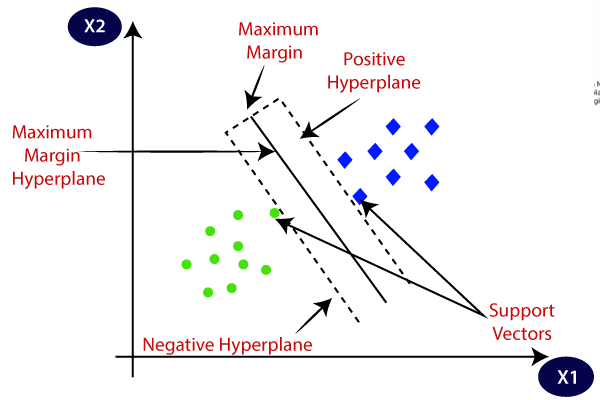

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [31]:
param_grid = [
    {'C': 0.1, 'kernel': 'linear'},
    {'C': 1, 'kernel': 'linear'},
    {'C': 10, 'kernel': 'linear'},
    {'C': 1, 'kernel': 'poly', 'degree': 2},
    {'C': 1, 'kernel': 'poly', 'degree': 3},
    {'C': 1, 'kernel': 'rbf', 'gamma': 'scale'},
    {'C': 1, 'kernel': 'rbf', 'gamma': 'auto'},
]
# scale >>  depends on number of features and data variancs
#auto >> ignore data variance and deponnds only on number of features in distance

In [32]:
def mrr_score(y_true, y_scores):
    order = np.argsort(-y_scores)
    y_true_ordered = y_true.iloc[order].values
    for idx, val in enumerate(y_true_ordered, start=1):
        if val == 1:
            return 1.0 / idx
    return 0.0

In [33]:
def precision_at_k(y_true, y_scores, k=5):
    order = np.argsort(y_scores)[::-1]
    y_true_sorted = np.take(y_true, order[:k])
    return np.sum(y_true_sorted) / k

def mean_reciprocal_rank(y_true, y_scores):
    order = np.argsort(y_scores)[::-1]
    y_true_sorted = np.take(y_true, order)
    for i, rel in enumerate(y_true_sorted, start=1):
        if rel:
            return 1.0 / i
    return 0.0

def evaluate_ranking(y_true, y_scores, groups, k=5):
    precisions = []
    mrrs = []
    for g in np.unique(groups):
        mask = groups == g
        y_true_g = y_true[mask].values
        y_scores_g = y_scores[mask]
        precisions.append(precision_at_k(y_true_g, y_scores_g, k))
        mrrs.append(mean_reciprocal_rank(y_true_g, y_scores_g))
    return {
        f'Precision@{k}': np.mean(precisions),
        'MRR': np.mean(mrrs)
    }

In [39]:
results = []
for params in param_grid:
    model = SVC(**params, probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)

    val_scores = model.predict_proba(X_val_scaled)[:, 1]
    test_scores = model.predict_proba(X_test_scaled)[:, 1]

    val_metrics = evaluate_ranking(y_val, val_scores, groups_val, k=5)
    test_metrics = evaluate_ranking(y_test, test_scores, groups_test, k=5)
    val_df = X_val.copy()
    val_df['cv_id'] = groups_val.values
    val_df['score'] = val_scores
    val_df['target'] = y_val.values

    val_df['rank'] = val_df.groupby('cv_id')['score'].rank(method='first', ascending=False)
    top5_val = val_df[val_df['rank'] <= 5].sort_values(['cv_id', 'rank'])
    train_scores = model.predict_proba(X_train_scaled)[:, 1]
    train_metrics = evaluate_ranking(y_train, train_scores, groups_train, k=5)


    results.append({
    'params': params,
    'train_precision@5': train_metrics[f'Precision@5'],
    'train_mrr': train_metrics['MRR'],
    'val_precision@5': val_metrics[f'Precision@5'],
    'val_mrr': val_metrics['MRR'],
    'test_precision@5': test_metrics[f'Precision@5'],
    'test_mrr': test_metrics['MRR']
      })



In [40]:
res_df = pd.DataFrame(results)


res_df['params_str'] = res_df['params'].apply(lambda x: str(x))
res_df

,params,train_precision@5,train_mrr,val_precision@5,val_mrr,test_precision@5,test_mrr,params_str
0,"{'C': 0.1, 'kernel': 'linear'}",0.90,0.975000,0.766667,1.000000,0.766667,0.916667,"{'C': 0.1, 'kernel': 'linear'}"
1,"{'C': 1, 'kernel': 'linear'}",0.90,0.975000,0.766667,1.000000,0.766667,0.916667,"{'C': 1, 'kernel': 'linear'}"
2,"{'C': 10, 'kernel': 'linear'}",0.90,0.975000,0.766667,1.000000,0.766667,0.916667,"{'C': 10, 'kernel': 'linear'}"
3,"{'C': 1, 'kernel': 'poly', 'degree': 2}",0.82,0.842129,0.766667,0.805556,0.633333,0.719444,"{'C': 1, 'kernel': 'poly', 'degree': 2}"
4,"{'C': 1, 'kernel': 'poly', 'degree': 3}",0.95,1.000000,0.733333,0.763889,0.700000,0.733333,"{'C': 1, 'kernel': 'poly', 'degree': 3}"
5,"{'C': 1, 'kernel': 'rbf', 'gamma': 'scale'}",0.92,1.000000,0.766667,1.000000,0.733333,1.000000,"{'C': 1, 'kernel': 'rbf', 'gamma': 'scale'}"
6,"{'C': 1, 'kernel': 'rbf', 'gamma': 'auto'}",0.92,1.000000,0.766667,1.000000,0.733333,1.000000,"{'C': 1, 'kernel': 'rbf', 'gamma': 'auto'}"


#Results

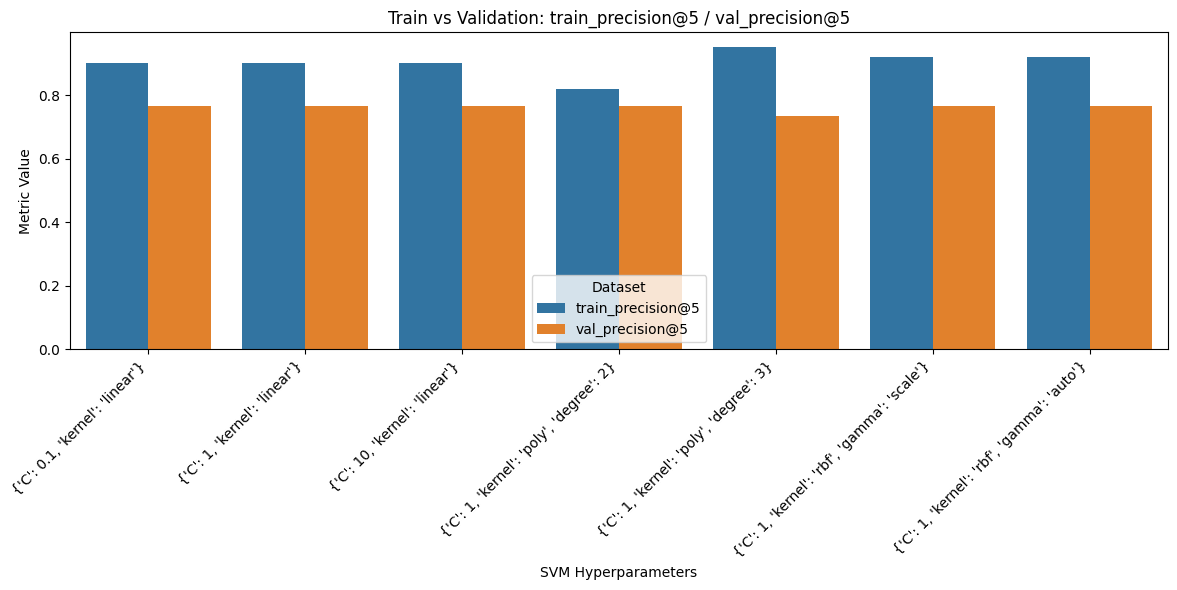

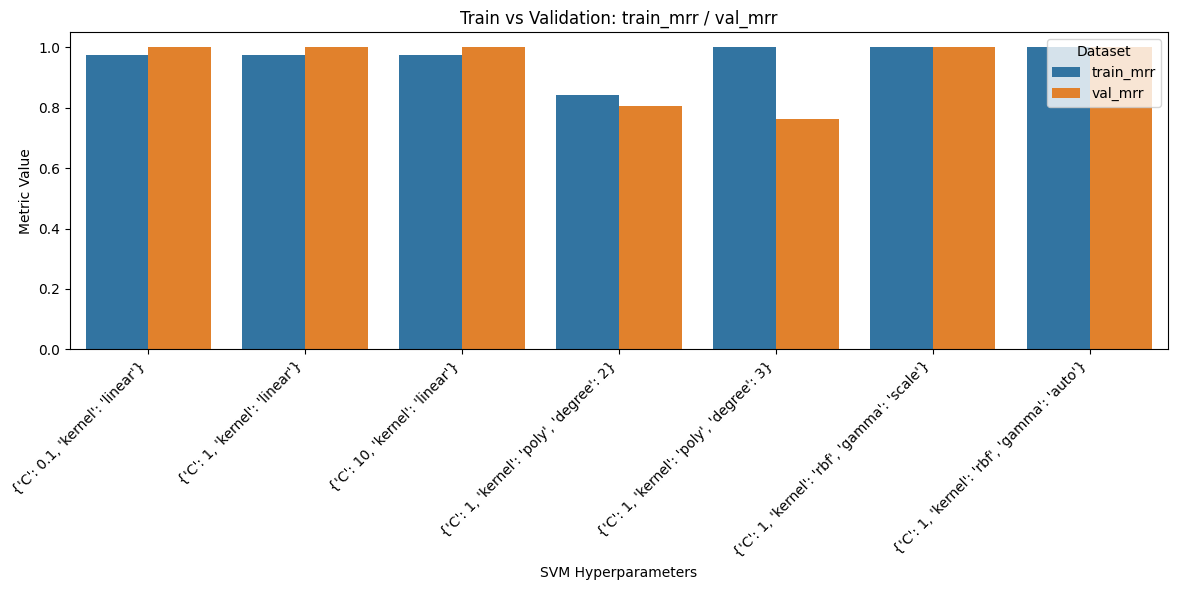

In [41]:
metrics_train = ['train_precision@5', 'train_mrr']
metrics_val = ['val_precision@5', 'val_mrr']
metrics_test = ['test_precision@5', 'test_mrr']
for train_metric, val_metric in zip(metrics_train, metrics_val):
    plt.figure(figsize=(12,6))
    plot_df = pd.melt(res_df,
                      id_vars=['params_str'],
                      value_vars=[train_metric, val_metric],
                      var_name='Dataset',
                      value_name='Metric')
    sns.barplot(data=plot_df, x='params_str', y='Metric', hue='Dataset')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Train vs Validation: {train_metric} / {val_metric}')
    plt.ylabel('Metric Value')
    plt.xlabel('SVM Hyperparameters')
    plt.tight_layout()
    plt.show()


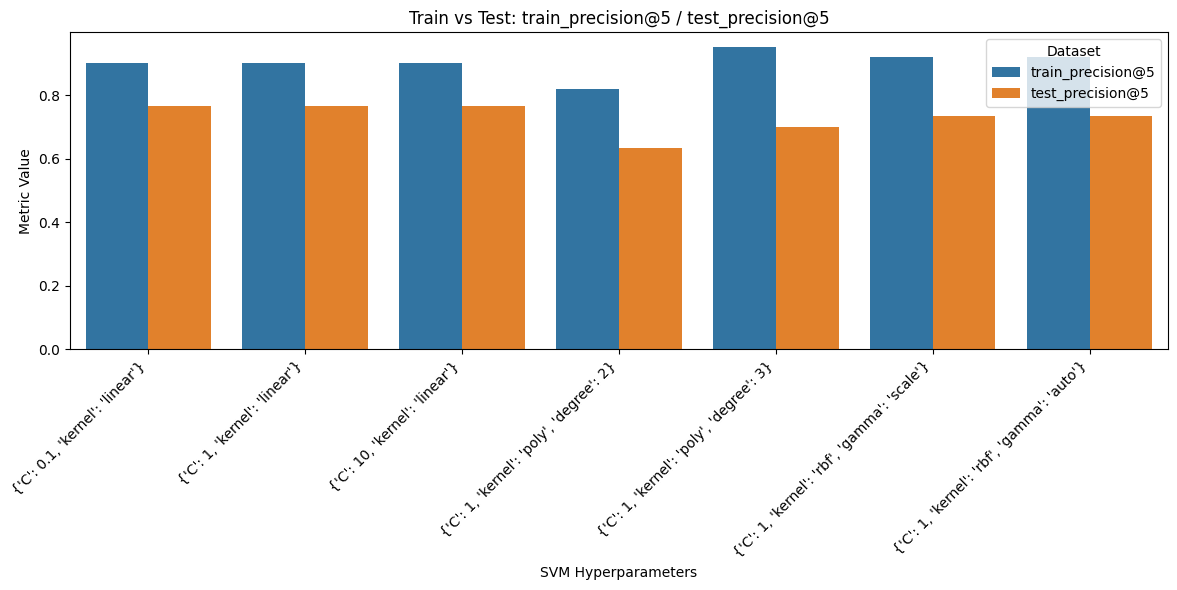

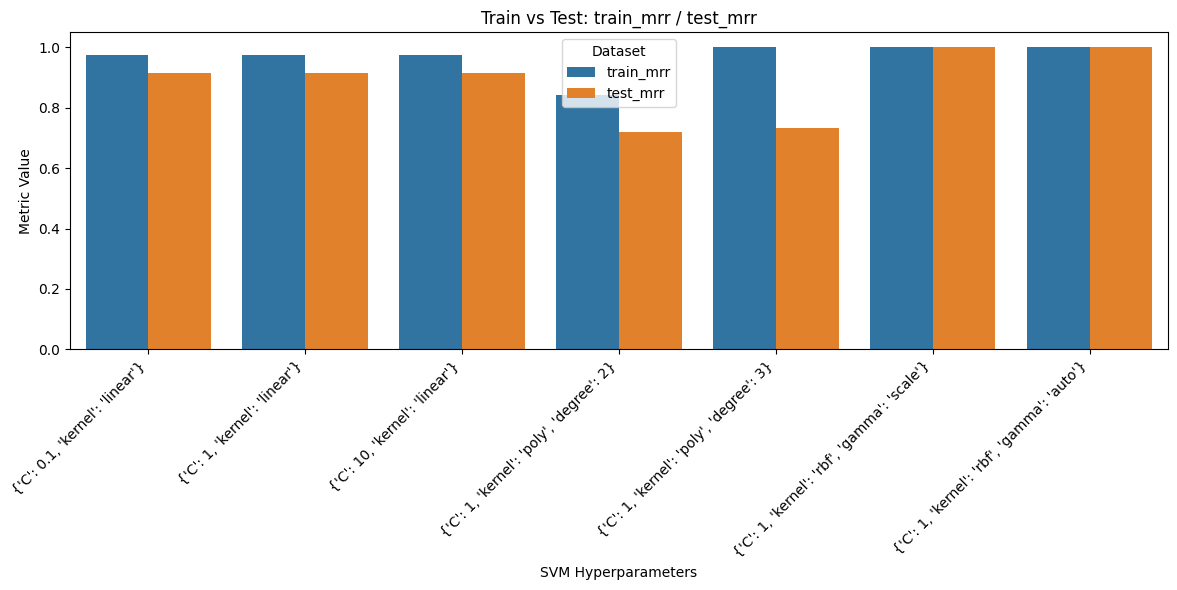

In [42]:
for train_metric, test_metric in zip(metrics_train, metrics_test):
    plt.figure(figsize=(12,6))
    plot_df = pd.melt(res_df,
                      id_vars=['params_str'],
                      value_vars=[train_metric, test_metric],
                      var_name='Dataset',
                      value_name='Metric')
    sns.barplot(data=plot_df, x='params_str', y='Metric', hue='Dataset')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Train vs Test: {train_metric} / {test_metric}')
    plt.ylabel('Metric Value')
    plt.xlabel('SVM Hyperparameters')
    plt.tight_layout()
    plt.show()


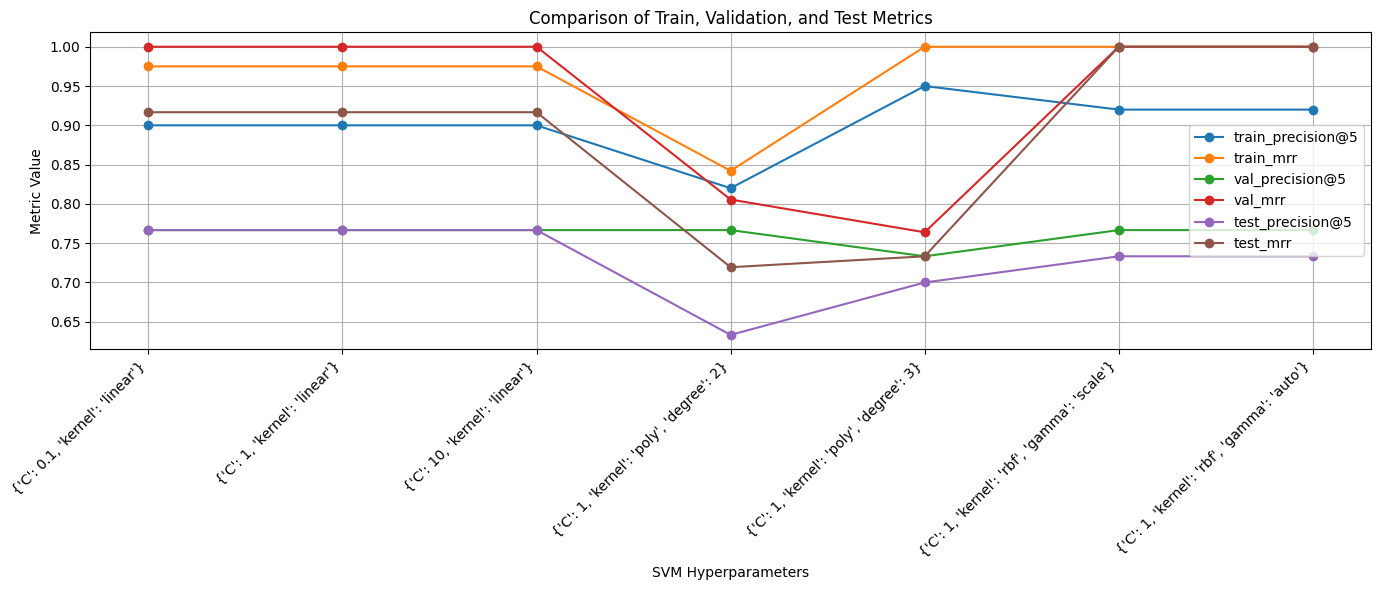

In [43]:
plt.figure(figsize=(14,6))
for metric in metrics_train + metrics_val + metrics_test:
    plt.plot(res_df['params_str'], res_df[metric], marker='o', label=metric)

plt.xticks(rotation=45, ha='right')
plt.title('Comparison of Train, Validation, and Test Metrics')
plt.xlabel('SVM Hyperparameters')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
